In [ ]:
import pandas as pd

print("TikTok Analytics Project Started!")

TikTok Analytics Project Started!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
!wget -O tiktok_data.jsonl https://raw.githubusercontent.com/Crawlora-org/tiktok-engagement-data/main/data/videos.jsonl

--2026-09-01 07:59:18--  https://raw.githubusercontent.com/Crawlora-org/tiktok-engagement-data/main/data/videos.jsonl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1152339 (1.1M) [text/plain]
Saving to: ‘tiktok_data.jsonl’

tiktok_data.jsonl   100%[===================>]   1.10M  --.-KB/s    in 0.1s    

2026-09-01 07:59:18 (10.4 MB/s) - ‘tiktok_data.jsonl’ saved [1152339/1152339]



In [ ]:
# Load TikTok dataset

df = pd.read_json("tiktok_data.jsonl", lines=True)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 4509
Columns: 12


In [ ]:
df.head()


,niche,keyword,video_id,author,followers,views,likes,comments,shares,saves,engagement_rate,created_at
0,Finance,personal finance,7653180701570878464,lifewithmegannicole,231100,11400,1323,98,24,30,0.1294,2026-06-19 18:50:19+00:00
1,Finance,personal finance,7653177627624147968,lifewithmegannicole,231100,19700,1907,64,31,40,0.1037,2026-06-19 18:38:29+00:00
2,Finance,personal finance,7652756302921206784,ericsfinancials,8968,66200,1249,22,279,158,0.0258,2026-06-18 15:23:06+00:00
3,Finance,personal finance,7652553236141886464,apetrovs,15700,159300,5666,196,260,593,0.0422,2026-06-18 02:15:20+00:00
4,Finance,personal finance,7647320299830004736,doseofzayra,52700,365700,97000,395,1870,19400,0.3245,2026-06-03 23:49:21+00:00


In [ ]:
# Check all columns in our dataset

print("Column names:")
print(df.columns.tolist())

Column names:
['niche', 'keyword', 'video_id', 'author', 'followers', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'created_at']


In [ ]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4509 entries, 0 to 4508
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   niche            4509 non-null   object             
 1   keyword          4509 non-null   object             
 2   video_id         4509 non-null   int64              
 3   author           4509 non-null   object             
 4   followers        4509 non-null   int64              
 5   views            4509 non-null   int64              
 6   likes            4509 non-null   int64              
 7   comments         4509 non-null   int64              
 8   shares           4509 non-null   int64              
 9   saves            4509 non-null   int64              
 10  engagement_rate  4509 non-null   float64            
 11  created_at       4509 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(1), int64(7), object(3)
memory usage: 422

In [ ]:
# Check missing values in each column

df.isnull().sum()


,0
niche,0
keyword,0
video_id,0
author,0
followers,0
views,0
likes,0
comments,0
shares,0
saves,0


In [ ]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Statistical summary of numerical columns

df.describe()

,video_id,followers,views,likes,comments,shares,saves,engagement_rate
count,4.509000e+03,4.509000e+03,4.509000e+03,4.509000e+03,4509.00000,4.509000e+03,4.509000e+03,4509.000000
mean,7.526288e+18,5.371008e+05,5.444642e+06,5.801290e+05,3528.55356,5.931177e+04,7.832387e+04,0.117540
std,1.433041e+17,3.101979e+06,1.326407e+07,1.473558e+06,12434.54899,2.764672e+05,1.910225e+05,0.076984
min,6.763937e+18,0.000000e+00,1.000000e+04,8.000000e+00,0.00000,0.000000e+00,1.000000e+00,0.000700
25%,7.447974e+18,7.864000e+03,2.035000e+05,9.609000e+03,84.00000,4.620000e+02,1.832000e+03,0.054500
50%,7.585252e+18,4.410000e+04,9.041000e+05,6.590000e+04,395.00000,3.499000e+03,1.260000e+04,0.106200
75%,7.641418e+18,2.411000e+05,5.000000e+06,4.724000e+05,2189.00000,2.520000e+04,6.120000e+04,0.170200
max,7.653279e+18,1.621000e+08,2.526000e+08,2.340000e+07,309600.00000,9.600000e+06,4.200000e+06,0.546400


In [ ]:
# Check the number of unique values in each column

df.nunique()

,0
niche,13
keyword,27
video_id,4509
author,3823
followers,2604
views,2328
likes,2984
comments,2084
shares,2895
saves,3054


In [ ]:
# Check data types of all columns

df.dtypes

,0
niche,object
keyword,object
video_id,int64
author,object
followers,int64
views,int64
likes,int64
comments,int64
shares,int64
saves,int64


In [ ]:
# Check for negative values

print("Negative followers:", (df["followers"] < 0).sum())
print("Negative views:", (df["views"] < 0).sum())
print("Negative likes:", (df["likes"] < 0).sum())
print("Negative comments:", (df["comments"] < 0).sum())
print("Negative shares:", (df["shares"] < 0).sum())


Negative followers: 0
Negative views: 0
Negative likes: 0
Negative comments: 0
Negative shares: 0


In [ ]:
# Check if likes are greater than views

print("Likes greater than views:", (df["likes"] > df["views"]).sum())

Likes greater than views: 0


In [ ]:
# Check date-related columns

print([col for col in df.columns if "date" in col.lower() or "time" in col.lower()])

[]


In [ ]:
# Display all columns clearly

for i, col in enumerate(df.columns, 1):
    print(i, "→", col)


1 → niche
2 → keyword
3 → video_id
4 → author
5 → followers
6 → views
7 → likes
8 → comments
9 → shares
10 → saves
11 → engagement_rate
12 → created_at


In [ ]:
# Convert created_at to proper datetime format

df["created_at"] = pd.to_datetime(df["created_at"])

print("Date conversion completed!")
print(df["created_at"].dtype)

Date conversion completed!
datetime64[ns, UTC]


In [ ]:
# Check the earliest and latest video dates

print("Earliest video:", df["created_at"].min())
print("Latest video:", df["created_at"].max())

Earliest video: 2019-11-27 10:49:35+00:00
Latest video: 2026-06-20 01:12:59+00:00


In [ ]:
# Create useful date columns

df["year"] = df["created_at"].dt.year
df["month"] = df["created_at"].dt.month
df["month_name"] = df["created_at"].dt.month_name()
df["day_name"] = df["created_at"].dt.day_name()

print("Date features created successfully!")

Date features created successfully!


In [ ]:
# Display the new date information

df[["created_at", "year", "month", "month_name", "day_name"]].head()

,created_at,year,month,month_name,day_name
0,2026-06-19 18:50:19+00:00,2026,6,June,Friday
1,2026-06-19 18:38:29+00:00,2026,6,June,Friday
2,2026-06-18 15:23:06+00:00,2026,6,June,Thursday
3,2026-06-18 02:15:20+00:00,2026,6,June,Thursday
4,2026-06-03 23:49:21+00:00,2026,6,June,Wednesday


In [ ]:
# Calculate key TikTok KPIs

total_views = df["views"].sum()
total_likes = df["likes"].sum()
total_comments = df["comments"].sum()
total_shares = df["shares"].sum()
total_saves = df["saves"].sum()

print("TikTok Analytics KPIs")
print("----------------------")
print("Total Views:", total_views)
print("Total Likes:", total_likes)
print("Total Comments:", total_comments)
print("Total Shares:", total_shares)
print("Total Saves:", total_saves)

TikTok Analytics KPIs
----------------------
Total Views: 24549892500
Total Likes: 2615801658
Total Comments: 15910248
Total Shares: 267436754
Total Saves: 353162351


In [ ]:
# Calculate overall engagement rate

total_engagement = total_likes + total_comments + total_shares

engagement_rate = (total_engagement / total_views) * 100

print("Total Engagement:", total_engagement)
print("Overall Engagement Rate:", round(engagement_rate, 2), "%")

Total Engagement: 2899148660
Overall Engagement Rate: 11.81 %


In [ ]:
# Top 10 TikTok videos by views

top_10_views = df.nlargest(10, "views")

top_10_views[
    ["author", "niche", "keyword", "views", "likes", "comments", "shares"]
]

,author,niche,keyword,views,likes,comments,shares
1931,dailychallenge0,Gaming,gaming,252600000,12100000,138600,4500000
708,fitness.usa3,Fitness,fitness,241600000,6900000,28600,238500
857,audioflag,Fitness,gym workout,212500000,4200000,150700,392500
501,longislandorganics,Motivation,motivation,201900000,23400000,107600,9600000
3750,phanthavongrisugl,Pets,cat,170300000,7200000,48500,2000000
1471,aflavorfulbite,Food,cooking recipe,159600000,11600000,31000,2800000
3672,catgivry,Pets,cat,143800000,18900000,135800,4100000
1943,thesmilyfam,Gaming,gaming,137000000,5100000,5258,18100
3706,dsnilo.ambul,Pets,cat,125900000,4700000,16800,1400000
3805,random_habit,Pets,cat,122400000,17000000,83000,454900


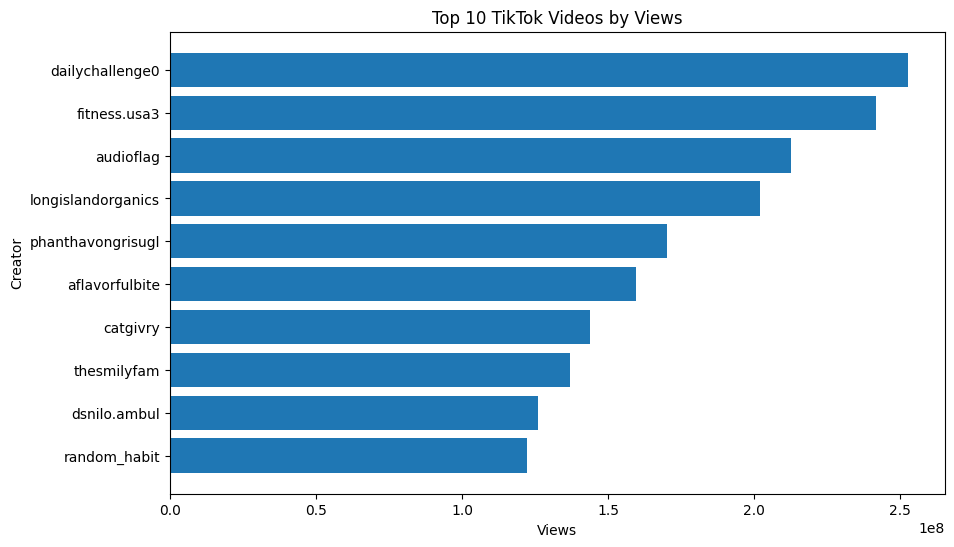

In [ ]:
# Top 10 videos by views - Bar Chart

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_views["author"].astype(str),
    top_10_views["views"]
)

plt.xlabel("Views")
plt.ylabel("Creator")
plt.title("Top 10 TikTok Videos by Views")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Top 10 creators by total views

top_creators = (
    df.groupby("author")["views"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_creators

,views
author,
zeeshan.eating,300800000
dailychallenge0,252600000
fitness.usa3,241600000
audioflag,212500000
longislandorganics,201900000
phanthavongrisugl,194200000
success.fitness,176249900
aflavorfulbite,171700000
catgivry,156900000


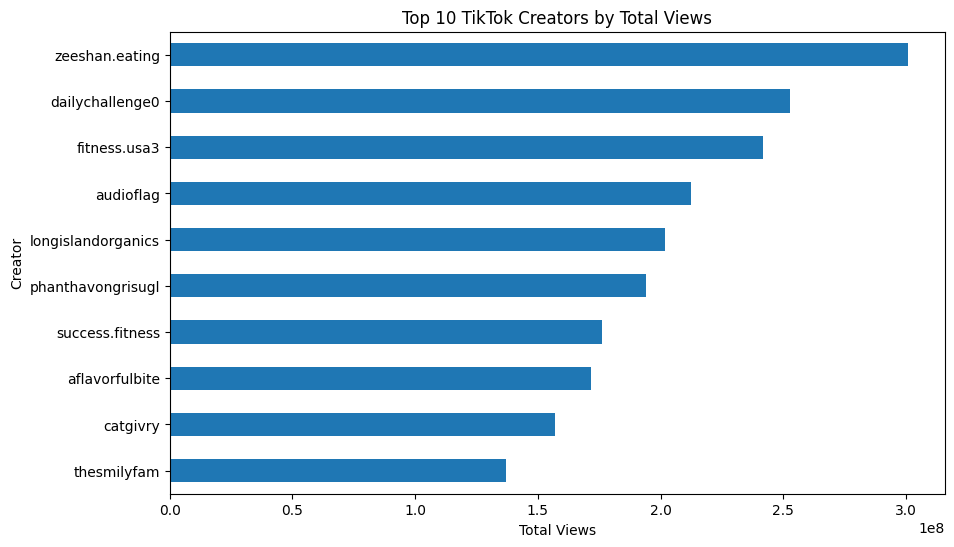

In [ ]:
# Top 10 creators by total views

plt.figure(figsize=(10, 6))

top_creators.sort_values().plot(kind="barh")

plt.xlabel("Total Views")
plt.ylabel("Creator")
plt.title("Top 10 TikTok Creators by Total Views")

plt.show()

In [ ]:
# Total views by niche

niche_views = (
    df.groupby("niche")["views"]
    .sum()
    .sort_values(ascending=False)
)

niche_views

,views
niche,
Pets,4823880300
Gaming,3049636800
Travel,2557476400
Fitness,2279416500
Motivation,2235275900
Comedy,2092076400
Food,2089364500
Fashion,1465111400
Beauty,1179626600


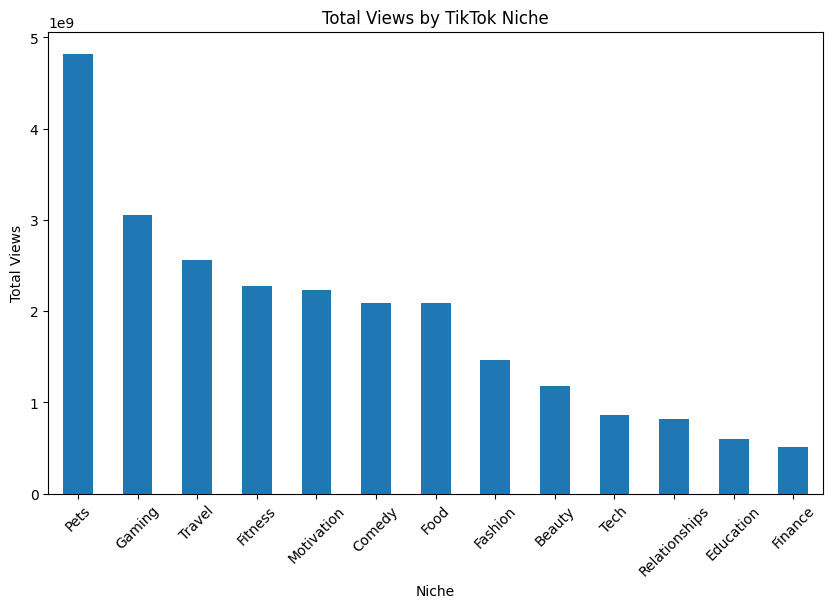

In [ ]:
# Views by niche chart

plt.figure(figsize=(10,6))

niche_views.plot(kind="bar")

plt.xlabel("Niche")
plt.ylabel("Total Views")
plt.title("Total Views by TikTok Niche")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Average engagement rate by niche

engagement_niche = (
    df.groupby("niche")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

engagement_niche

,engagement_rate
niche,
Education,0.164687
Motivation,0.154953
Comedy,0.136650
Travel,0.135070
Pets,0.133211
Relationships,0.131773
Fashion,0.127006
Beauty,0.105481
Fitness,0.097950


In [ ]:
# Average TikTok engagement metrics

print("Average Likes:", round(df["likes"].mean(), 2))
print("Average Comments:", round(df["comments"].mean(), 2))
print("Average Shares:", round(df["shares"].mean(), 2))
print("Average Saves:", round(df["saves"].mean(), 2))

Average Likes: 580129.0
Average Comments: 3528.55
Average Shares: 59311.77
Average Saves: 78323.87


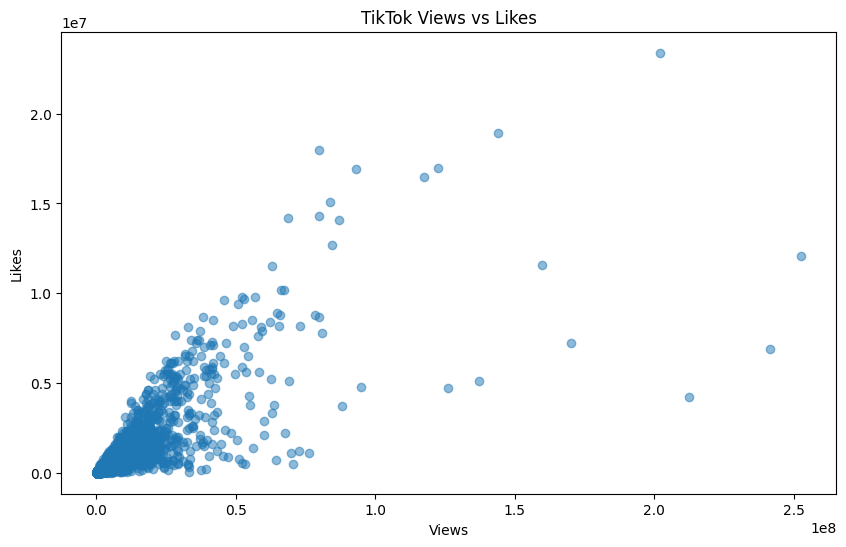

In [ ]:
# Likes vs Views

plt.figure(figsize=(10, 6))

plt.scatter(df["views"], df["likes"], alpha=0.5)

plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("TikTok Views vs Likes")

plt.show()

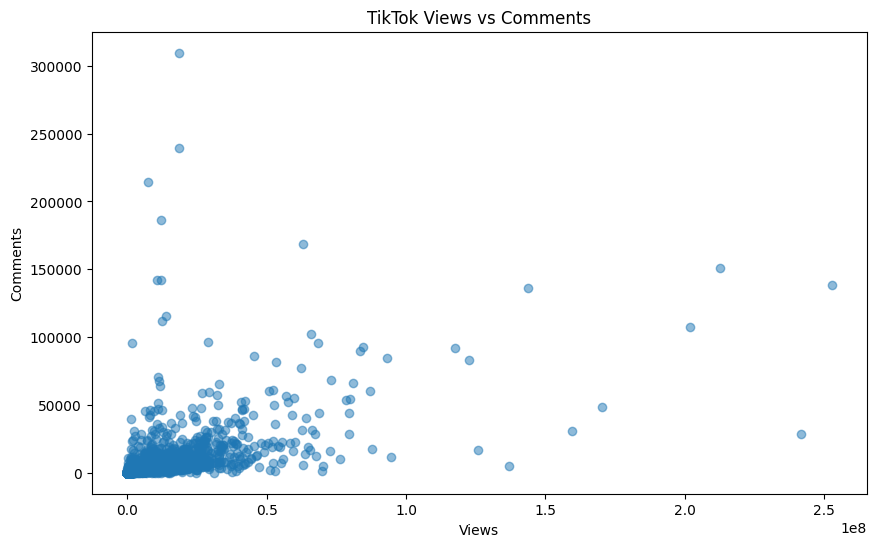

In [ ]:
# Comments vs Views

plt.figure(figsize=(10, 6))

plt.scatter(df["views"], df["comments"], alpha=0.5)

plt.xlabel("Views")
plt.ylabel("Comments")
plt.title("TikTok Views vs Comments")

plt.show()

In [ ]:
# Top 10 keywords by total views

top_keywords = (
    df.groupby("keyword")["views"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_keywords

,views
keyword,
cat,3089059400
gaming,2735541200
travel,2385777400
dog,1734820900
comedy,1680223700
motivation,1560104600
cooking recipe,1477612700
fitness,1033979200
gym workout,1017712700


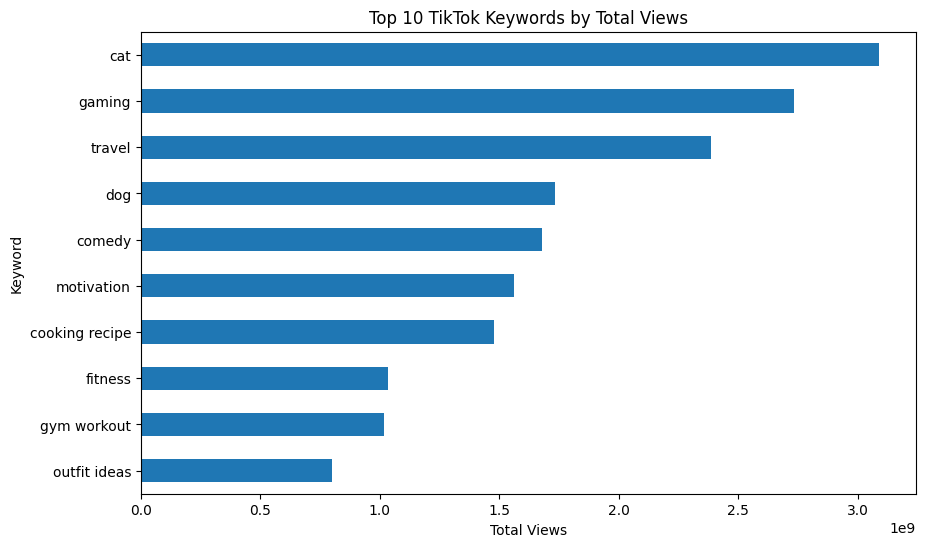

In [ ]:
# Top 10 keywords by total views

plt.figure(figsize=(10, 6))

top_keywords.sort_values().plot(kind="barh")

plt.xlabel("Total Views")
plt.ylabel("Keyword")
plt.title("Top 10 TikTok Keywords by Total Views")

plt.show()

In [ ]:
# Top 10 keywords by average engagement rate

top_engagement_keywords = (
    df.groupby("keyword")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_engagement_keywords

,engagement_rate
keyword,
study tips,0.172010
self improvement,0.168093
cat,0.159082
funny skit,0.152774
how to study,0.149244
motivation,0.145066
travel,0.144115
fashion,0.138166
relationship advice,0.136289


In [ ]:
# Total views by month

monthly_views = (
    df.groupby("month")["views"]
    .sum()
    .sort_index()
)

monthly_views

,views
month,
1,2516239400
2,2163371700
3,1920597200
4,1849968100
5,3014801900
6,2139555600
7,1582153800
8,1935443100
9,2049213900


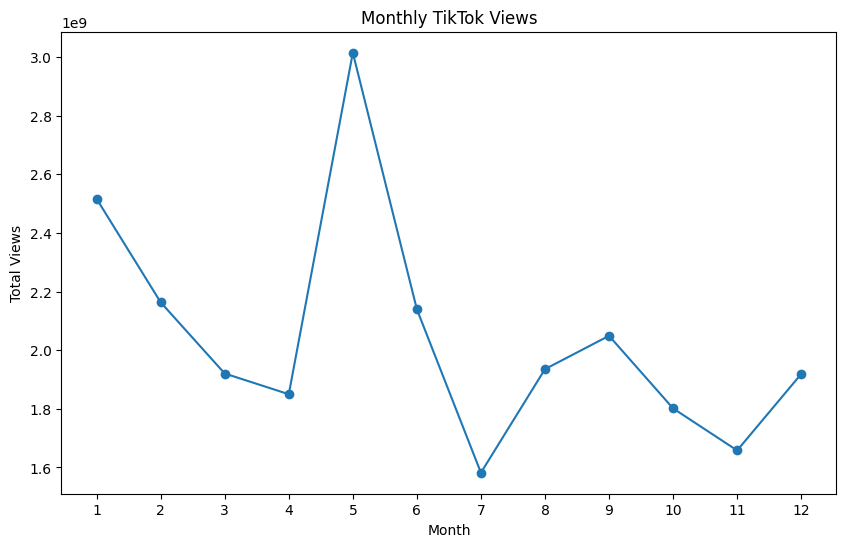

In [ ]:
# Monthly views trend

plt.figure(figsize=(10, 6))

plt.plot(monthly_views.index, monthly_views.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Views")
plt.title("Monthly TikTok Views")

plt.xticks(range(1, 13))

plt.show()

In [ ]:
# Average engagement rate by month

monthly_engagement = (
    df.groupby("month")["engagement_rate"]
    .mean()
    .sort_index()
)

monthly_engagement

,engagement_rate
month,
1,0.114764
2,0.122594
3,0.118805
4,0.116868
5,0.115291
6,0.120994
7,0.113972
8,0.132300
9,0.110112


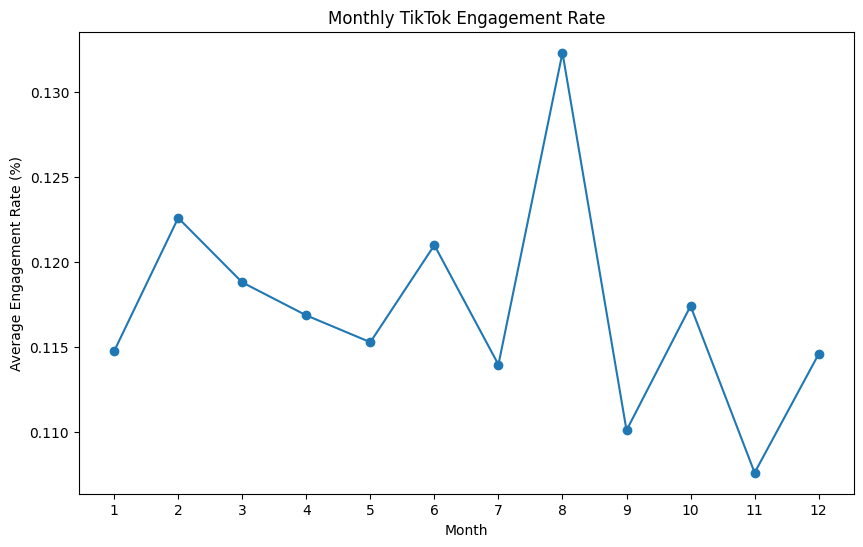

In [ ]:
# Monthly engagement rate

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_engagement.index,
    monthly_engagement.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Engagement Rate (%)")
plt.title("Monthly TikTok Engagement Rate")

plt.xticks(range(1, 13))

plt.show()

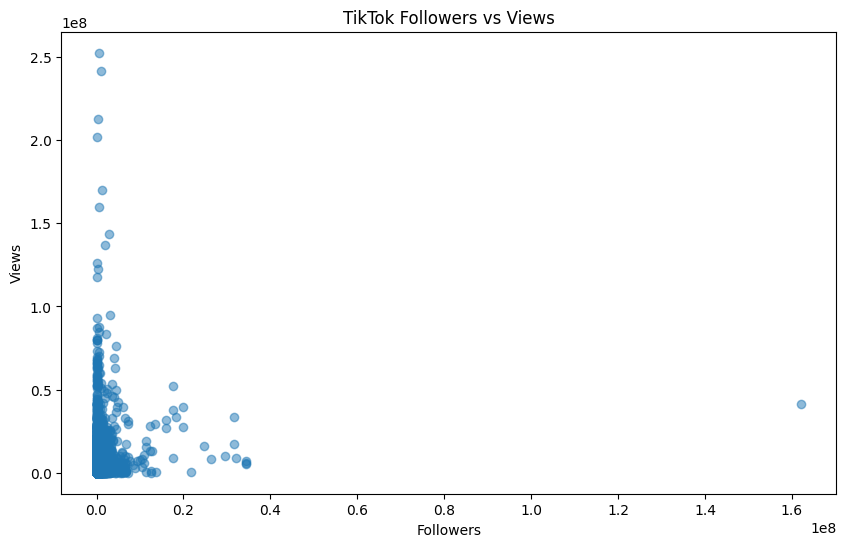

In [ ]:
# Followers vs Views

plt.figure(figsize=(10, 6))

plt.scatter(
    df["followers"],
    df["views"],
    alpha=0.5
)

plt.xlabel("Followers")
plt.ylabel("Views")
plt.title("TikTok Followers vs Views")

plt.show()

In [ ]:
# Calculate correlation between followers and views

correlation = df["followers"].corr(df["views"])

print("Correlation between Followers and Views:",
      round(correlation, 2))

Correlation between Followers and Views: 0.1


In [ ]:
# Top 10 videos by engagement rate

top_engagement = (
    df.sort_values("engagement_rate", ascending=False)
      .head(10)
)

top_engagement[
    ["author", "niche", "keyword", "views",
     "likes", "comments", "shares", "engagement_rate"]
]

,author,niche,keyword,views,likes,comments,shares,engagement_rate
3531,golddogzeusofficial,Pets,dog,1100000,459200,453,114700,0.5464
571,hmosoul,Motivation,self improvement,1100000,271200,138,271300,0.5104
3081,leeuchio,Comedy,funny skit,304200,99500,768,7601,0.4167
3798,attatudeandstevie,Pets,cat,1000000,350800,959,43400,0.4113
3818,babysaltshaker,Pets,cat,752500,259900,745,27800,0.4014
3708,h8untted1,Pets,cat,10300000,3100000,13400,601300,0.3895
547,moniqueesmithxo,Motivation,self improvement,343300,106200,519,2943,0.3803
3747,funny.cat.098,Pets,cat,1700000,495600,564,90000,0.3699
3567,lmazaa,Pets,dog,2500000,772800,538,117400,0.3695
2683,paracha7781,Fashion,fashion,12200000,3900000,186600,208200,0.3659


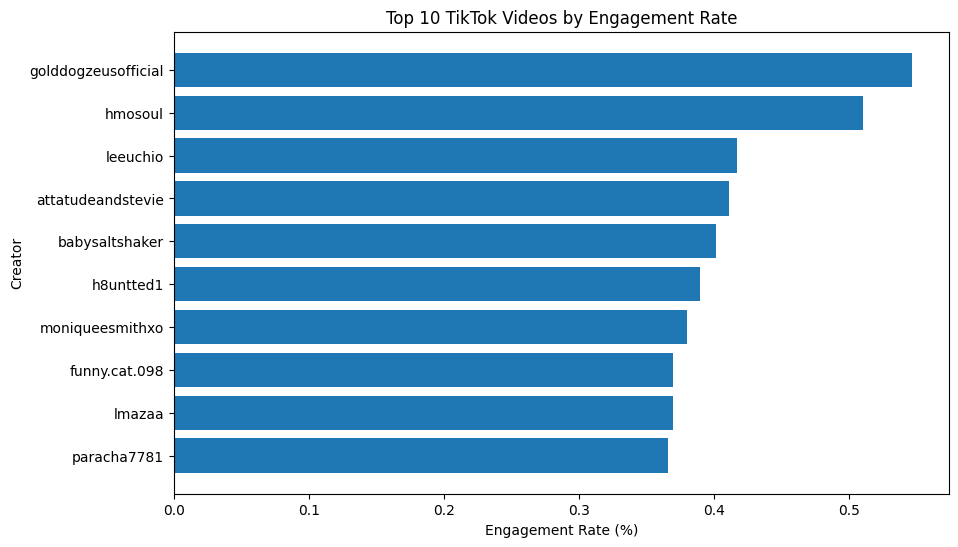

In [ ]:
# Top 10 videos by engagement rate

plt.figure(figsize=(10, 6))

plt.barh(
    top_engagement["author"].astype(str),
    top_engagement["engagement_rate"]
)

plt.xlabel("Engagement Rate (%)")
plt.ylabel("Creator")
plt.title("Top 10 TikTok Videos by Engagement Rate")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Top 10 TikTok videos by shares

top_shared = (
    df.sort_values("shares", ascending=False)
      .head(10)
)

top_shared[
    ["author", "niche", "keyword", "views",
     "likes", "comments", "shares"]
]

,author,niche,keyword,views,likes,comments,shares
501,longislandorganics,Motivation,motivation,201900000,23400000,107600,9600000
2119,jenacouture,Travel,travel,93100000,16900000,84600,6000000
1931,dailychallenge0,Gaming,gaming,252600000,12100000,138600,4500000
3672,catgivry,Pets,cat,143800000,18900000,135800,4100000
3817,skropzy_,Pets,cat,68600000,14200000,95400,4100000
2216,fallandchristmasarecool,Travel,travel,117600000,16500000,92300,3200000
3820,e.b.g5,Pets,cat,36600000,7400000,11600,3100000
3797,kittynyasha,Pets,cat,52200000,9800000,60900,2900000
1471,aflavorfulbite,Food,cooking recipe,159600000,11600000,31000,2800000
3767,jiannelovee,Pets,cat,79800000,14300000,54000,2600000


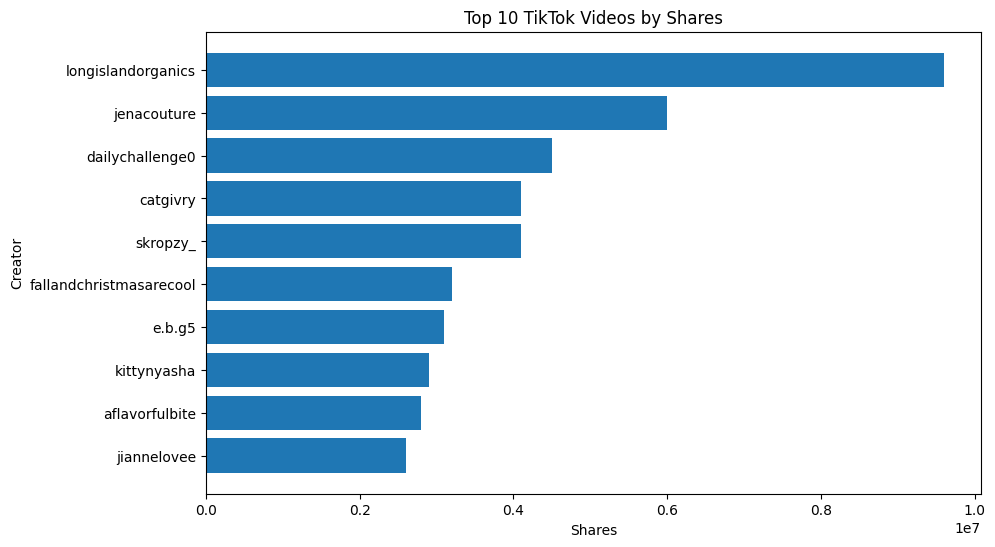

In [ ]:
# Top 10 videos by shares

plt.figure(figsize=(10, 6))

plt.barh(
    top_shared["author"].astype(str),
    top_shared["shares"]
)

plt.xlabel("Shares")
plt.ylabel("Creator")
plt.title("Top 10 TikTok Videos by Shares")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Top 10 TikTok videos by saves

top_saved = (
    df.sort_values("saves", ascending=False)
      .head(10)
)

top_saved[
    ["author", "niche", "keyword", "views",
     "likes", "comments", "shares", "saves"]
]

,author,niche,keyword,views,likes,comments,shares,saves
1471,aflavorfulbite,Food,cooking recipe,159600000,11600000,31000,2800000,4200000
2216,fallandchristmasarecool,Travel,travel,117600000,16500000,92300,3200000,2200000
713,arielyu.fit,Fitness,fitness,46200000,2400000,12600,233700,1900000
3777,lishiyin_,Pets,cat,83600000,15100000,89600,2100000,1900000
3672,catgivry,Pets,cat,143800000,18900000,135800,4100000,1900000
1851,iiamderick,Gaming,gaming,41000000,3900000,52000,1200000,1900000
3805,random_habit,Pets,cat,122400000,17000000,83000,454900,1800000
1624,vkusnie_resepti_,Food,cooking recipe,87900000,3700000,17300,638600,1700000
2067,bryanwoess,Travel,travel,87100000,14100000,59900,1300000,1500000
929,jette.fit,Fitness,gym workout,24200000,2300000,2989,104500,1500000


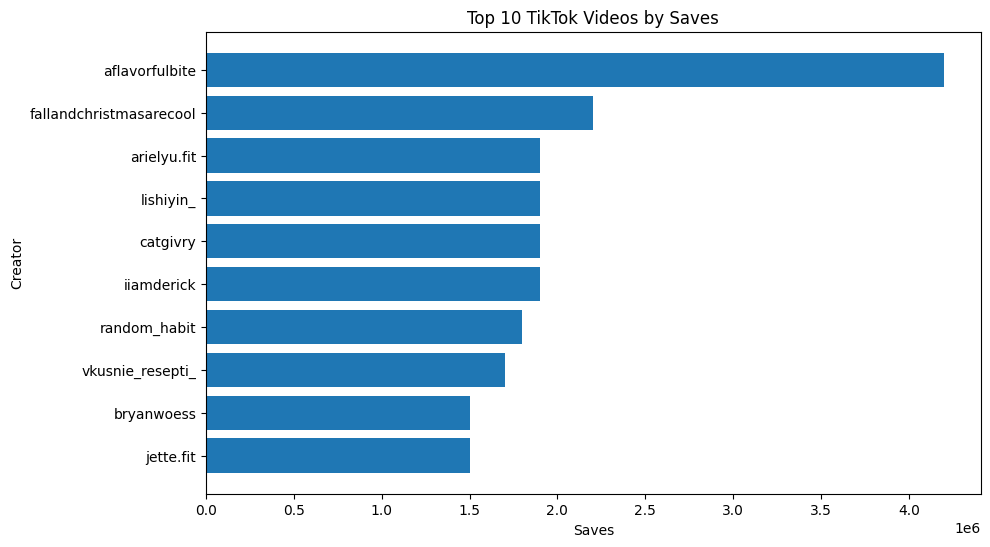

In [ ]:
# Top 10 videos by saves

plt.figure(figsize=(10, 6))

plt.barh(
    top_saved["author"].astype(str),
    top_saved["saves"]
)

plt.xlabel("Saves")
plt.ylabel("Creator")
plt.title("Top 10 TikTok Videos by Saves")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Create a TikTok Analytics Summary

summary = pd.DataFrame({
    "Metric": [
        "Total Videos",
        "Total Views",
        "Total Likes",
        "Total Comments",
        "Total Shares",
        "Total Saves",
        "Overall Engagement Rate"
    ],
    "Value": [
        len(df),
        total_views,
        total_likes,
        total_comments,
        total_shares,
        total_saves,
        round(engagement_rate, 2)
    ]
})

summary

,Metric,Value
0,Total Videos,4.509000e+03
1,Total Views,2.454989e+10
2,Total Likes,2.615802e+09
3,Total Comments,1.591025e+07
4,Total Shares,2.674368e+08
5,Total Saves,3.531624e+08
6,Overall Engagement Rate,1.181000e+01


In [ ]:
# Format large numbers for easier reading

summary_formatted = summary.copy()

summary_formatted["Value"] = summary_formatted["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"
)

summary_formatted

,Metric,Value
0,Total Videos,"4,509.00"
1,Total Views,"24,549,892,500.00"
2,Total Likes,"2,615,801,658.00"
3,Total Comments,"15,910,248.00"
4,Total Shares,"267,436,754.00"
5,Total Saves,"353,162,351.00"
6,Overall Engagement Rate,11.81


In [ ]:
# Professional KPI Summary

print("=" * 50)
print("          TIKTOK ANALYTICS SUMMARY")
print("=" * 50)

print(f"Total Videos           : {len(df):,}")
print(f"Total Views            : {total_views:,}")
print(f"Total Likes            : {total_likes:,}")
print(f"Total Comments         : {total_comments:,}")
print(f"Total Shares           : {total_shares:,}")
print(f"Total Saves            : {total_saves:,}")
print(f"Engagement Rate        : {engagement_rate:.2f}%")

print("=" * 50)

          TIKTOK ANALYTICS SUMMARY
Total Videos           : 4,509
Total Views            : 24,549,892,500
Total Likes            : 2,615,801,658
Total Comments         : 15,910,248
Total Shares           : 267,436,754
Total Saves            : 353,162,351
Engagement Rate        : 11.81%


In [ ]:
# Key Business Insights

# 1. Best niche by total views
best_niche = niche_views.idxmax()
best_niche_views = niche_views.max()

# 2. Best creator by total views
best_creator = top_creators.idxmax()
best_creator_views = top_creators.max()

# 3. Best keyword by total views
best_keyword = top_keywords.idxmax()
best_keyword_views = top_keywords.max()

# 4. Best month by total views
best_month = monthly_views.idxmax()
best_month_views = monthly_views.max()

# 5. Highest engagement keyword
best_engagement_keyword = top_engagement_keywords.idxmax()
best_keyword_engagement = top_engagement_keywords.max()

# 6. Followers vs Views correlation
followers_views_corr = df["followers"].corr(df["views"])

print("========== KEY BUSINESS INSIGHTS ==========")

print(f"1. Best niche: {best_niche}")
print(f"   Total views: {best_niche_views:,}")

print(f"\n2. Top creator: {best_creator}")
print(f"   Total views: {best_creator_views:,}")

print(f"\n3. Top keyword: {best_keyword}")
print(f"   Total views: {best_keyword_views:,}")

print(f"\n4. Best month: {best_month}")
print(f"   Total views: {best_month_views:,}")

print(f"\n5. Highest-engagement keyword: {best_engagement_keyword}")
print(f"   Average engagement rate: {best_keyword_engagement:.2f}%")

print(f"\n6. Followers vs Views correlation: {followers_views_corr:.2f}")

print("============================================")

========== KEY BUSINESS INSIGHTS ==========
1. Best niche: Pets
   Total views: 4,823,880,300

2. Top creator: zeeshan.eating
   Total views: 300,800,000

3. Top keyword: cat
   Total views: 3,089,059,400

4. Best month: 5
   Total views: 3,014,801,900

5. Highest-engagement keyword: study tips
   Average engagement rate: 0.17%

6. Followers vs Views correlation: 0.10


In [ ]:
# Step 34: Final Project Conclusion

print("=" * 60)
print("              TIKTOK ANALYTICS CONCLUSION")
print("=" * 60)

print(f"""
1. {best_niche} was the highest-performing niche based on total views,
   generating {best_niche_views:,} views.

2. {best_creator} was the top creator based on total views,
   with {best_creator_views:,} total views.

3. The keyword "{best_keyword}" generated the highest total views,
   with {best_keyword_views:,} views.

4. Month {best_month} recorded the highest total views,
   reaching {best_month_views:,} views.

5. The keyword "{best_engagement_keyword}" had the highest average
   engagement rate at {best_keyword_engagement:.2f}%.

6. The correlation between followers and views was
   {followers_views_corr:.2f}, showing the relationship between
   creator followers and video reach.

Overall, this analysis demonstrates how TikTok data can be used
to understand audience behavior, identify high-performing content,
and support data-driven content strategies.
""")

print("=" * 60)

              TIKTOK ANALYTICS CONCLUSION

1. Pets was the highest-performing niche based on total views,
   generating 4,823,880,300 views.

2. zeeshan.eating was the top creator based on total views,
   with 300,800,000 total views.

3. The keyword "cat" generated the highest total views,
   with 3,089,059,400 views.

4. Month 5 recorded the highest total views,
   reaching 3,014,801,900 views.

5. The keyword "study tips" had the highest average
   engagement rate at 0.17%.

6. The correlation between followers and views was
   0.10, showing the relationship between
   creator followers and video reach.

Overall, this analysis demonstrates how TikTok data can be used
to understand audience behavior, identify high-performing content,
and support data-driven content strategies.

